In [2]:
import pandas as pd

df = pd.read_csv("PS_20174392719_1491204439457_log.csv")

print(df.shape)
print(df.head())
print(df.columns)
print(df.dtypes)
print(df.isnull().sum())
print(df["isFraud"].value_counts())
print(df["isFraud"].value_counts(normalize=True))

(6362620, 11)
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  
Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nam

### Initial Questions

1. What am I trying to predict?
   → isFraud

2. What information would be available at prediction time?
   → transaction type, amount, balances, etc.

3. How imbalanced is the dataset?
   → what % of transactions are actually fraud?

### pandas Representation

pd.read_csv -> converts a csv file into a DataFrame

DataFrame.shape -> [no. of rows, no. of columns]

DataFrame.head() -> displays first 5 rows of DataFrame

DataFrame.columns -> lists column names
- ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud']

DataFrame.dtypes -> shows each column's data type

DataFrame.isnull().sum() -> counts missing values per column

DataFrame["column_name"].value_counts() -> counts each class of the column_name,
- e.g. "isFraud" -> 0,1
- value_counts(normalize_True) -> displays the counts as proportions instead

In [ ]:
subset = df[df["type"].isin(["TRANSFER", "CASH_OUT"])].copy()

for title, transactions in [("All transactions", df), ("Transfers and cash-outs only", subset)]:
    print(f"\n=== {title} ===")

    # count transactions and frauds, and calculate the fraud proportion by type
    fraud_by_type = transactions.groupby("type")["isFraud"].agg(
        ["count", "sum", "mean"]
    ).sort_values("mean", ascending=False)
    print("\nFraud by transaction type (mean is a proportion):")
    print(fraud_by_type)

    # compare transaction amounts in legitimate vs fraudulent transactions
    transactAmounts = transactions.groupby("isFraud")["amount"].describe()
    print("\nTransaction amounts by fraud label:")
    print(transactAmounts)

    # calculate old minus new balances for both original and destination accounts
    balance_changes = transactions[["isFraud"]].copy()
    balance_changes["diffbalanceOrig"] = (
        transactions["oldbalanceOrg"] - transactions["newbalanceOrig"]
    )
    balance_changes["diffbalanceDest"] = (
        transactions["oldbalanceDest"] - transactions["newbalanceDest"]
    )
    print("\nBalance differences by fraud label (old minus new):")
    print(balance_changes.groupby("isFraud")[["diffbalanceOrig", "diffbalanceDest"]].describe())


=== All transactions ===

Fraud by transaction type (mean is a proportion):
            count   sum      mean
type                             
TRANSFER   532909  4097  0.007688
CASH_OUT  2237500  4116  0.001840
CASH_IN   1399284     0  0.000000
DEBIT       41432     0  0.000000
PAYMENT   2151495     0  0.000000

Transaction amounts by fraud label:
             count          mean           std   min         25%        50%  \
isFraud                                                                       
0        6354407.0  1.781970e+05  5.962370e+05  0.01   13368.395   74684.72   
1           8213.0  1.467967e+06  2.404253e+06  0.00  127091.330  441423.44   

                75%          max  
isFraud                           
0         208364.76  92445516.64  
1        1517771.48  10000000.00  

Balance differences by fraud label (old minus new):
        diffbalanceOrig                                                    \
                  count          mean           std        mi

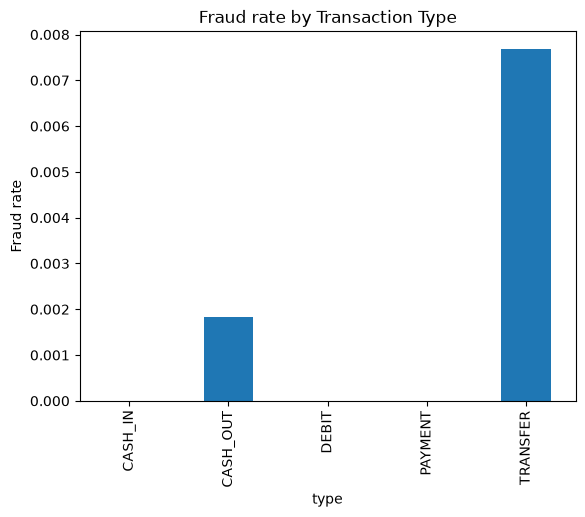

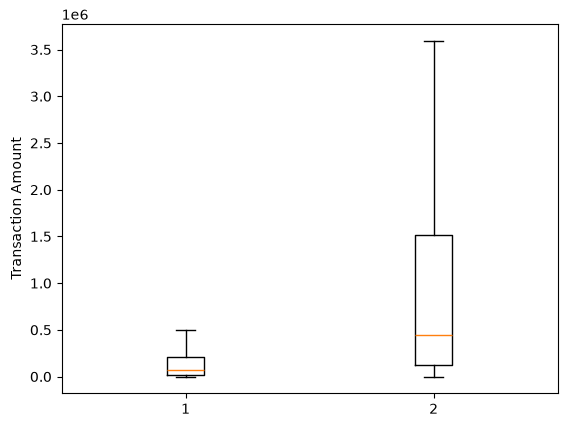

In [23]:
import matplotlib.pyplot as plt

df.groupby("type")["isFraud"].mean().plot(kind="bar")

plt.ylabel("Fraud rate")
plt.title("Fraud rate by Transaction Type")
plt.show()

fraud = df[df["isFraud"] == 1]
legit = df[df["isFraud"] == 0]

plt.boxplot(
    [legit["amount"], fraud["amount"]],
    label=["Legitimate", "Fraud"],
    showfliers=False
)

plt.ylabel("Transaction Amount")
plt.show()